In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chidinmacharityigwe","key":"43d62a025606e9686d565b0eee6f2c68"}'}

In [3]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)

if os.path.exists('kaggle.json'):
    shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle API key ready.")

Kaggle API key ready.


In [4]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q -o skin-cancer-mnist-ham10000.zip -d /content/ham10000_data
print("Dataset downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:53<00:00, 105MB/s]

Dataset downloaded and extracted.


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, load_img, img_to_array

In [6]:
df = pd.read_csv('/content/ham10000_data/HAM10000_metadata.csv')

image_dir_1 = '/content/ham10000_data/HAM10000_images_part_1'
image_dir_2 = '/content/ham10000_data/HAM10000_images_part_2'

def get_image_path(image_id):
    p1 = os.path.join(image_dir_1, image_id + '.jpg')
    p2 = os.path.join(image_dir_2, image_id + '.jpg')
    if os.path.exists(p1):
        return p1
    elif os.path.exists(p2):
        return p2
    return None

df['image_path'] = df['image_id'].apply(get_image_path)
df = df.dropna(subset=['image_path']).copy()

print(df.shape)
print(df['dx'].value_counts())

(10015, 8)
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [7]:
# smaller balanced sample for stability
df_sample = df.groupby('dx', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 100), random_state=42)
).reset_index(drop=True)

print(df_sample.shape)
print(df_sample['dx'].value_counts())

(700, 8)
dx
akiec    100
bcc      100
bkl      100
df       100
mel      100
nv       100
vasc     100
Name: count, dtype: int64


/tmp/ipykernel_24000/3891082010.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('dx', group_keys=False).apply(


In [8]:
# encode labels
label_map = {label: idx for idx, label in enumerate(sorted(df_sample['dx'].unique()))}
df_sample['label'] = df_sample['dx'].map(label_map)

print(label_map)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [9]:
train_df, val_df = train_test_split(
    df_sample,
    test_size=0.2,
    stratify=df_sample['label'],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)

Train: (560, 9)
Val: (140, 9)


In [10]:
IMG_SIZE = 224

def load_images_and_labels(dataframe):
    images = []
    labels = []
    for _, row in dataframe.iterrows():
        img = load_img(row['image_path'], target_size=(IMG_SIZE, IMG_SIZE))
        img = img_to_array(img) / 255.0
        images.append(img)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

X_train, y_train = load_images_and_labels(train_df)
X_val, y_val = load_images_and_labels(val_df)

y_train_cat = to_categorical(y_train, num_classes=len(label_map))
y_val_cat = to_categorical(y_val, num_classes=len(label_map))

print(X_train.shape, y_train_cat.shape)
print(X_val.shape, y_val_cat.shape)

(560, 224, 224, 3) (560, 7)
(140, 224, 224, 3) (140, 7)


In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(label_map), activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=5,
    batch_size=32
)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.2214 - loss: 2.0961 - val_accuracy: 0.3929 - val_loss: 1.6668
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4268 - loss: 1.5589 - val_accuracy: 0.3929 - val_loss: 1.5809
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4714 - loss: 1.3981 - val_accuracy: 0.4000 - val_loss: 1.5297
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5196 - loss: 1.2870 - val_accuracy: 0.4429 - val_loss: 1.4975
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5661 - loss: 1.1779 - val_accuracy: 0.4429 - val_loss: 1.5108


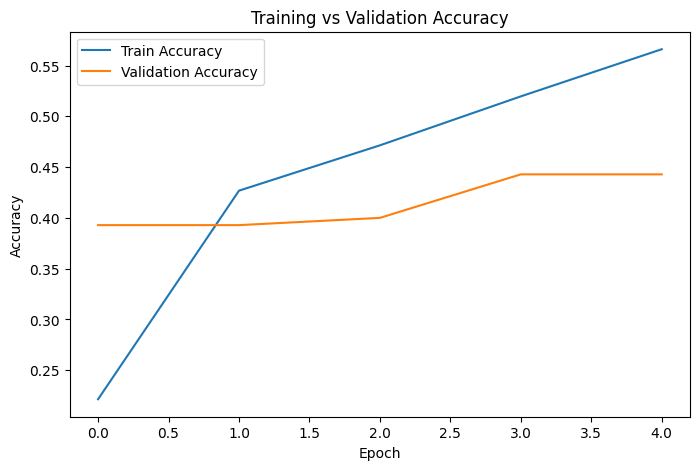

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [14]:
loss, accuracy = model.evaluate(X_val, y_val_cat, verbose=0)
print(f"Validation Accuracy: {accuracy:.2f}")

Validation Accuracy: 0.44


In [15]:
model.save('melanincare_ai_prototype_v1.h5')
print("Model saved successfully.")

Model saved successfully.
